# 1. Importaciones

Carga las librerías necesarias para comunicarse con Arduino, procesar los datos y generar gráficos.

In [8]:
# Importaciones
import serial
from serial.tools import list_ports
import pandas as pd
import time

# 2. Detectar Arduino

Lista los puertos seriales disponibles e identifica el dispositivo Arduino conectado.

In [9]:
# Listar dispositivos seriales e identificar Arduino
palabras_arduino = ("arduino", "usbmodem", "usb serial", "ch340", "cp210", "ftdi", "wch")
puertos = list(list_ports.comports())
puertos_arduino = []

if not puertos:
    print("No se encontraron dispositivos seriales.")
else:
    print("Dispositivos seriales encontrados:\n")
    for puerto in puertos:
        informacion = " ".join(str(valor or "") for valor in [puerto.device, puerto.description, puerto.manufacturer, puerto.product, puerto.hwid]).lower()
        es_arduino = any(palabra in informacion for palabra in palabras_arduino)
        etiqueta = " <-- Arduino probable" if es_arduino else ""
        print(f"{puerto.device}: {puerto.description} | fabricante: {puerto.manufacturer or 'N/D'}{etiqueta}")
        if es_arduino:
            puertos_arduino.append(puerto.device)

if len(puertos_arduino) == 1:
    print(f"\nArduino identificado en: {puertos_arduino[0]}")
else:
    print("\nNo se pudo identificar un unico Arduino automaticamente.")

Dispositivos seriales encontrados:

/dev/cu.URT1: n/a | fabricante: N/D
/dev/cu.BLTH: n/a | fabricante: N/D
/dev/cu.Bluetooth-Incoming-Port: n/a | fabricante: N/D
/dev/cu.FersJBLFlip3: n/a | fabricante: N/D
/dev/cu.usbmodemE8F60AAABD882: UNO WiFi R4 CMSIS-DAP | fabricante: Arduino <-- Arduino probable

Arduino identificado en: /dev/cu.usbmodemE8F60AAABD882


# 3. Configurar y conectar

Define el puerto, la velocidad serial y la cantidad de ciclos antes de abrir la conexión.

In [10]:
# Configuracion y conexion
PORT = puertos_arduino[0] if len(puertos_arduino) == 1 else "COM7"
BAUD = 921600
N_CICLOS = 5
MUESTRA_INICIO = 1
ser = serial.Serial(PORT, BAUD, timeout=1)
time.sleep(2)
ser.reset_input_buffer()
print("Conectado a", PORT)

Conectado a /dev/cu.usbmodemE8F60AAABD882


# 4. Capturar ciclos

Lee las muestras enviadas por Arduino y guarda cinco ciclos completos de carga y descarga.

In [11]:
# Capturar ciclos
datos = []
ciclo = 0
muestras_ciclo = 0
capturando = False
ultimo_estado = None
print(f"Esperando la muestra {MUESTRA_INICIO} enviada por Arduino...")

try:
    while ciclo < N_CICLOS:
        linea = ser.readline().decode("utf-8", errors="ignore").strip()
        if not linea or linea.startswith("estado"):
            continue
        partes = linea.split(",")
        if len(partes) != 4:
            continue
        try:
            estado = partes[0]
            muestra = int(partes[1])
            tiempo_us = int(partes[2])
            adc = int(partes[3])
        except ValueError:
            continue

        if not capturando:
            if muestra == MUESTRA_INICIO:
                capturando = True
                ciclo = 0
                muestras_ciclo = 0
                print(f"Comenzando ciclo {ciclo + 1} desde la muestra {MUESTRA_INICIO}.")
            else:
                continue
        elif ultimo_estado == "OFF" and estado == "ON":
            print(f"Ciclo {ciclo + 1} finalizado: {muestras_ciclo} muestras capturadas.")
            ciclo += 1
            if ciclo >= N_CICLOS:
                break
            muestras_ciclo = 0
            print(f"Comenzando ciclo {ciclo + 1}.")

        datos.append([ciclo, estado, muestra, tiempo_us, adc])
        muestras_ciclo += 1
        ultimo_estado = estado
finally:
    if ser.is_open:
        ser.close()
    print("Puerto serial principal liberado.")

print(f"Captura finalizada: {min(ciclo + 1, N_CICLOS)} ciclos completos.")

Esperando la muestra 1 enviada por Arduino...
Comenzando ciclo 1 desde la muestra 1.
Ciclo 1 finalizado: 1299 muestras capturadas.
Comenzando ciclo 2.
Ciclo 2 finalizado: 2600 muestras capturadas.
Comenzando ciclo 3.
Ciclo 3 finalizado: 2600 muestras capturadas.
Comenzando ciclo 4.
Ciclo 4 finalizado: 2600 muestras capturadas.
Comenzando ciclo 5.
Ciclo 5 finalizado: 2600 muestras capturadas.
Puerto serial principal liberado.
Captura finalizada: 5 ciclos completos.


# 5. Crear el DataFrame

Convierte las mediciones en una tabla y calcula el voltaje y el tiempo en milisegundos.

In [12]:
# Crear DataFrame
df = pd.DataFrame(datos, columns=["ciclo", "estado", "muestra", "tiempo_us", "ADC"])
df["voltaje_V"] = df["ADC"] * 3.3 / 4095
df["muestra_ciclo"] = df["muestra"]
# Arduino envia el tiempo relativo desde la muestra 0 de cada ciclo.
df["tiempo_ms"] = df["tiempo_us"] / 1000
print("\nListo. Muestras:", len(df))
df.head()


Listo. Muestras: 11699


,ciclo,estado,muestra,tiempo_us,ADC,voltaje_V,muestra_ciclo,tiempo_ms
0,0,OFF,1,26,2388,1.924396,1,0.026
1,0,OFF,2,49,2386,1.922784,2,0.049
2,0,OFF,3,73,2385,1.921978,3,0.073
3,0,OFF,4,96,2380,1.917949,4,0.096
4,0,OFF,5,120,2378,1.916337,5,0.120


# 6. Graficar carga y descarga

Superpone los ciclos y separa visualmente las fases de carga y descarga.

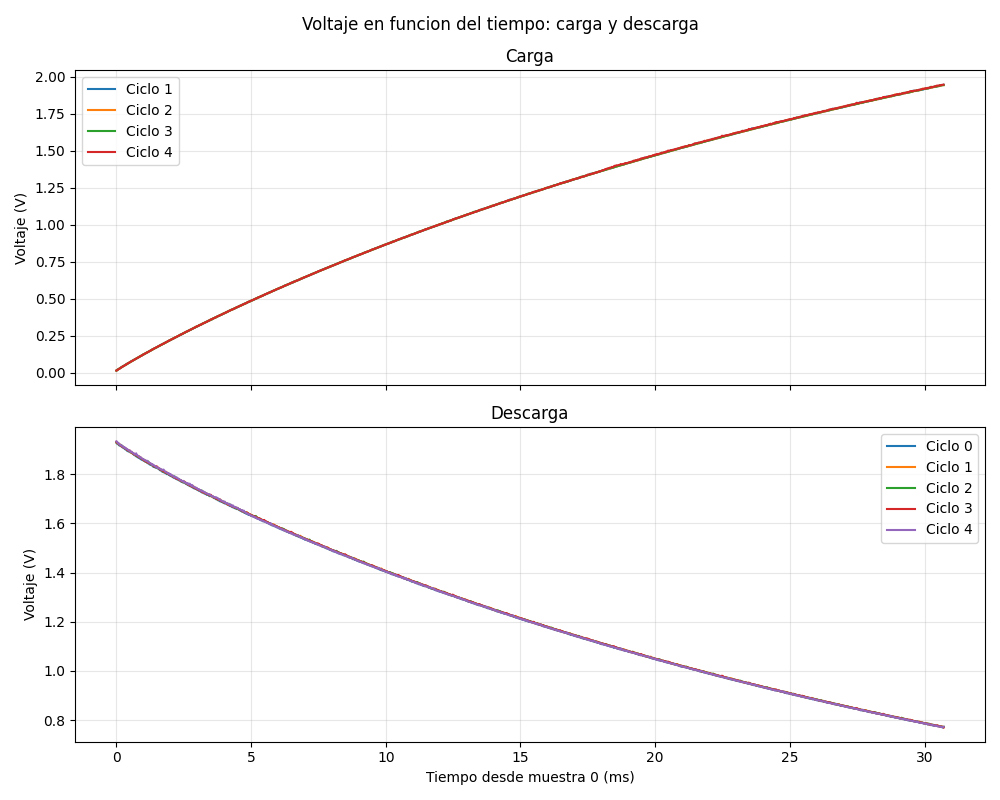

In [13]:
# Graficar carga y descarga
import matplotlib.pyplot as plt

if df.empty:
    print("No hay datos para graficar.")
else:
    fig, ejes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for estado, (eje, nombre_fase) in {"ON": (ejes[0], "Carga"), "OFF": (ejes[1], "Descarga")}.items():
        datos_fase = df[df["estado"] == estado]
        for ciclo, datos_ciclo in datos_fase.groupby("ciclo"):
            eje.plot(datos_ciclo["tiempo_ms"], datos_ciclo["voltaje_V"], label=f"Ciclo {ciclo}")
        eje.set_title(nombre_fase)
        eje.set_ylabel("Voltaje (V)")
        eje.grid(True, alpha=0.3)
        eje.legend()
    ejes[1].set_xlabel("Tiempo desde muestra 0 (ms)")
    fig.suptitle("Voltaje en funcion del tiempo: carga y descarga")
    plt.tight_layout()
    plt.show()

# 7. Medir resistencias y estimar RC

Realiza cinco mediciones de un segundo, permite cambiar la resistencia y estima la constante de tiempo RC.

In [ ]:
# Cinco ciclos completos, uno por cada Enter, y estimacion de RC y R
import numpy as np
from scipy.optimize import curve_fit

N_MEDICIONES_RC = 5
CAPACIDAD_F = 15e-6
TIMEOUT_CICLO_S = 5.0


def estimar_tau(datos_fase, fase):
    if len(datos_fase) < 3:
        return np.nan

    tiempo = datos_fase["tiempo_s"].to_numpy()
    voltaje = datos_fase["voltaje_V"].to_numpy()

    if fase == "ON":
        def modelo(t, vi, vf, tau):
            return vf - (vf - vi) * np.exp(-t / tau)
    else:
        def modelo(t, vi, vf, tau):
            return vf + (vi - vf) * np.exp(-t / tau)

    try:
        parametros, _ = curve_fit(
            modelo,
            tiempo,
            voltaje,
            p0=[voltaje[0], voltaje[-1], max(tiempo[-1] / 3, 1e-6)],
            bounds=([-np.inf, -np.inf, 1e-9], [np.inf, np.inf, np.inf]),
            maxfev=10000,
        )
    except (RuntimeError, ValueError):
        return np.nan

    return parametros[2]


def leer_dato_serial():
    while True:
        linea = ser_rc.readline().decode("utf-8", errors="ignore").strip()
        if not linea or linea.startswith("estado"):
            continue

        partes = linea.split(",")
        if len(partes) != 4:
            continue

        try:
            return {
                "estado": partes[0].strip().upper(),
                "muestra": int(partes[1]),
                "tiempo_s": int(partes[2]) / 1_000_000,
                "ADC": int(partes[3]),
            }
        except ValueError:
            continue


def capturar_ciclo_rc(numero_medicion):
    datos_ciclo = []
    estado_anterior = None
    inicio_captura = False
    carga_terminada = False
    inicio_timeout = time.perf_counter()

    print(
        f"Medicion {numero_medicion}: "
        "esperando transicion OFF -> ON..."
    )

    while time.perf_counter() - inicio_timeout < TIMEOUT_CICLO_S:
        dato = leer_dato_serial()
        estado_actual = dato["estado"]

        if estado_anterior is None:
            estado_anterior = estado_actual
            continue

        transicion_inicio = (
            not inicio_captura
            and estado_anterior == "OFF"
            and estado_actual == "ON"
        )
        transicion_carga = (
            inicio_captura
            and not carga_terminada
            and estado_anterior == "ON"
            and estado_actual == "OFF"
        )
        transicion_fin = (
            carga_terminada
            and estado_anterior == "OFF"
            and estado_actual == "ON"
        )

        if transicion_inicio:
            inicio_captura = True
            print(f"Medicion {numero_medicion}: carga iniciada.")
            datos_ciclo.append({"medicion": numero_medicion, **dato})
        elif inicio_captura and transicion_fin:
            break
        elif inicio_captura:
            datos_ciclo.append({"medicion": numero_medicion, **dato})

        if transicion_carga:
            carga_terminada = True
            print(f"Medicion {numero_medicion}: descarga iniciada.")

        estado_anterior = estado_actual

    if not inicio_captura or not carga_terminada:
        raise TimeoutError(
            f"Medicion {numero_medicion}: no se detecto "
            f"OFF -> ON -> OFF -> ON en {TIMEOUT_CICLO_S:.0f} segundos."
        )

    datos_ciclo = pd.DataFrame(datos_ciclo)
    muestras_on = (datos_ciclo["estado"] == "ON").sum()
    muestras_off = (datos_ciclo["estado"] == "OFF").sum()
    print(
        f"Medicion {numero_medicion} finalizada: "
        f"{len(datos_ciclo)} muestras "
        f"(carga={muestras_on}, descarga={muestras_off})."
    )
    return datos_ciclo.to_dict("records")


input(
    "Coloca la primera resistencia y presiona Enter "
    "para comenzar la captura..."
)

ser_rc = serial.Serial(PORT, BAUD, timeout=0.1)
time.sleep(1)
mediciones_rc = []
captura_interrumpida = False

try:
    for numero_medicion in range(1, N_MEDICIONES_RC + 1):
        if numero_medicion > 1:
            input(
                f"Cambia la resistencia y presiona Enter "
                f"para capturar el ciclo {numero_medicion}..."
            )

        mediciones_rc.extend(capturar_ciclo_rc(numero_medicion))
except TimeoutError as error:
    captura_interrumpida = True
    print(f"\nTIMEOUT: {error}")
    print("Captura detenida. Se conservaran los ciclos completos anteriores.")
finally:
    ser_rc.close()
    print("Puerto serial de RC liberado.")

df_rc = pd.DataFrame(mediciones_rc)

if df_rc.empty:
    print("No se recibieron ciclos completos.")
else:
    df_rc["voltaje_V"] = df_rc["ADC"] * 3.3 / 4095

    resumen_mediciones = df_rc.groupby("medicion").agg(
        muestras=("ADC", "size"),
        muestras_carga=("estado", lambda estados: (estados == "ON").sum()),
        muestras_descarga=("estado", lambda estados: (estados == "OFF").sum()),
        ADC_min=("ADC", "min"),
        ADC_max=("ADC", "max"),
        duracion_s=("tiempo_s", "max"),
    )
    print("\nResumen de datos capturados:")
    print(resumen_mediciones)

    resultados_rc = []
    for numero_medicion, datos_medicion in df_rc.groupby("medicion"):
        carga = estimar_tau(
            datos_medicion[datos_medicion["estado"] == "ON"],
            "ON",
        )
        descarga = estimar_tau(
            datos_medicion[datos_medicion["estado"] == "OFF"],
            "OFF",
        )
        promedio = np.nanmean([carga, descarga])
        resultados_rc.append({
            "medicion": numero_medicion,
            "RC_carga_s": carga,
            "RC_descarga_s": descarga,
            "RC_promedio_s": promedio,
            "R_carga_ohm": carga / CAPACIDAD_F,
            "R_descarga_ohm": descarga / CAPACIDAD_F,
            "R_promedio_ohm": promedio / CAPACIDAD_F,
        })

    resultados_rc = pd.DataFrame(resultados_rc)
    print(f"\nEstimacion con capacitor de {CAPACIDAD_F * 1e6:.0f} uF:")
    print(resultados_rc.round(3))

    fig, ejes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    fases = {
        "ON": (ejes[0], "Carga"),
        "OFF": (ejes[1], "Descarga"),
    }

    for estado, (eje, nombre_fase) in fases.items():
        datos_fase = df_rc[df_rc["estado"] == estado]
        for numero_medicion, datos_medicion in datos_fase.groupby("medicion"):
            datos_medicion = datos_medicion.sort_values("tiempo_s")
            eje.plot(
                datos_medicion["tiempo_s"],
                datos_medicion["voltaje_V"],
                label=f"Medicion {numero_medicion}",
            )
        eje.set_title(nombre_fase)
        eje.set_ylabel("Voltaje (V)")
        eje.grid(True, alpha=0.3)
        eje.legend()

    ejes[1].set_xlabel("Tiempo desde la muestra inicial (s)")
    fig.suptitle("Cinco ciclos superpuestos: carga y descarga")
    plt.tight_layout()
    plt.show()

# 8. Osciloscopio en vivo

Lee continuamente el puerto serial y muestra una ventana móvil con las últimas muestras. Detén la celda con el botón de interrupción para liberar el puerto.

In [15]:
# Osciloscopio en vivo con una unica salida actualizable
from collections import deque
from IPython.display import clear_output, display

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

VENTANA_S = 2.0
ACTUALIZAR_CADA_S = 0.1

if "ser_scope" in globals() and ser_scope.is_open:
    ser_scope.close()

ser_scope = serial.Serial(PORT, BAUD, timeout=0.05)
tiempo_scope = deque()
voltaje_scope = deque()
inicio_scope = time.perf_counter()
ultimo_dibujo = inicio_scope
contador_muestras = 0
contador_lineas_invalidas = 0
fig_scope, eje_scope = plt.subplots(figsize=(11, 5))
linea_scope, = eje_scope.plot([], [], color="tab:blue")
eje_scope.set_xlim(0, VENTANA_S)
eje_scope.set_ylim(0, 3.3)
eje_scope.set_xlabel("Tiempo (s)")
eje_scope.set_ylabel("Voltaje (V)")
eje_scope.set_title("Osciloscopio en vivo | esperando datos...")
eje_scope.grid(True, alpha=0.3)
fig_scope.tight_layout()
display(fig_scope)

try:
    while True:
        linea = ser_scope.readline().decode("utf-8", errors="ignore").strip()

        if linea:
            partes = linea.split(",")
            if len(partes) == 4:
                try:
                    adc = int(partes[3])
                except ValueError:
                    contador_lineas_invalidas += 1
                else:
                    tiempo_actual = time.perf_counter() - inicio_scope
                    tiempo_scope.append(tiempo_actual)
                    voltaje_scope.append(adc * 3.3 / 4095)
                    contador_muestras += 1
            elif not linea.startswith("estado"):
                contador_lineas_invalidas += 1

        tiempo_actual = time.perf_counter() - inicio_scope
        while tiempo_scope and tiempo_actual - tiempo_scope[0] > VENTANA_S:
            tiempo_scope.popleft()
            voltaje_scope.popleft()

        if tiempo_actual - ultimo_dibujo >= ACTUALIZAR_CADA_S:
            ultimo_dibujo = tiempo_actual
            linea_scope.set_data(list(tiempo_scope), list(voltaje_scope))
            eje_scope.set_xlim(
                max(0, tiempo_actual - VENTANA_S),
                max(VENTANA_S, tiempo_actual),
            )
            eje_scope.set_title(
                f"Osciloscopio en vivo | muestras: {contador_muestras} | "
                f"invalidas: {contador_lineas_invalidas}"
            )
            fig_scope.canvas.draw()
            clear_output(wait=True)
            display(fig_scope)

        plt.pause(0.001)
except KeyboardInterrupt:
    print("Osciloscopio detenido por el usuario.")
finally:
    if ser_scope.is_open:
        ser_scope.close()
    plt.close(fig_scope)
    clear_output(wait=True)
    print("Puerto serial del osciloscopio liberado.")

Puerto serial del osciloscopio liberado.
